# ACIS Insurance Risk Analytics: Exploratory Data Analysis

This notebook performs the first-stage exploratory data analysis for the AlphaCare Insurance Solutions (ACIS) insurance risk analytics challenge.

The goal is to understand data quality, claim risk, profitability, vehicle patterns, and customer/geographic segments before hypothesis testing and modeling.

## 1. Setup

Import the project utilities and plotting libraries. The notebook expects the dataset path to be updated in the `DATA_PATH` variable.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import (
    duplicate_row_summary,
    inspect_column_types,
    load_insurance_data,
    missing_value_summary,
    summarize_dataset,
)
from src.eda_utils import (
    add_risk_metrics,
    calculate_loss_ratio,
    calculate_margin,
    group_by_gender,
    group_by_province,
    group_by_vehicle_type,
    group_risk_summary,
)

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load the Dataset

The DVC-tracked raw dataset is at `data/raw/insurance_data.csv`. The loader supports CSV, TXT, Excel, Parquet, and JSON files.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "insurance_data.csv"

# If the file is pipe-delimited or semicolon-delimited, pass sep="|" or sep=";".
df = load_insurance_data(DATA_PATH)

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,1,False,0.0000,2346,0.0000,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,True,9883.0000,2334,9883.0000,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,1,False,0.0000,1697,0.0000,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,0,True,12134.0000,2370,12134.0000,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,4,False,0.0000,2582,0.0000,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


**Business interpretation:** Confirm that the dataset loaded successfully and that the visible columns match the expected ACIS insurance policy, customer, vehicle, premium, and claim fields. If the file path or delimiter is wrong, fix it before continuing.

## 3. Dataset Summary and Quality Checks

Summarize the dataset size, missing values, data types, and duplicate records before deeper analysis.

In [3]:
summary = summarize_dataset(df)
summary

{'rows': 10000,
 'columns': 21,
 'total_cells': 210000,
 'missing_cells': 0,
 'missing_percentage': 0.0,
 'duplicate_rows': 0,
 'duplicate_percentage': 0.0,
 'column_types': {'CustomerID': 'str',
  'Age': 'int64',
  'Gender': 'str',
  'Province': 'str',
  'VehicleType': 'str',
  'AnnualIncome': 'int64',
  'RiskScore': 'int64',
  'AnnualPremium': 'int64',
  'Deductible': 'int64',
  'NCD': 'int64',
  'PastClaims': 'int64',
  'Claimed': 'bool',
  'ClaimAmount': 'float64',
  'TotalPremium': 'int64',
  'TotalClaims': 'float64',
  'CoverType': 'str',
  'AutoMake': 'str',
  'VehicleModel': 'str',
  'CustomValueEstimate': 'int64',
  'ZipCode': 'int64',
  'TransactionDate': 'str'}}

In [4]:
column_types = inspect_column_types(df)
column_types.sort_values("missing_percentage", ascending=False).head(20)

,column,dtype,non_null_count,missing_count,missing_percentage,unique_count
0,CustomerID,str,10000,0,0.0000,10000
1,Age,int64,10000,0,0.0000,58
2,Gender,str,10000,0,0.0000,2
3,Province,str,10000,0,0.0000,5
4,VehicleType,str,10000,0,0.0000,4
5,AnnualIncome,int64,10000,0,0.0000,9545
6,RiskScore,int64,10000,0,0.0000,78
7,AnnualPremium,int64,10000,0,0.0000,2532
8,Deductible,int64,10000,0,0.0000,4
9,NCD,int64,10000,0,0.0000,6


In [5]:
missing_summary = missing_value_summary(df)
missing_summary[missing_summary["missing_count"] > 0].head(30)

,missing_count,missing_percentage


In [6]:
duplicate_row_summary(df)

{'duplicate_rows': 0, 'duplicate_percentage': 0.0}

**Business interpretation:** Missing values can reduce confidence in segment-level findings, especially if important fields such as claims, premium, province, gender, or vehicle attributes are incomplete. Duplicate records may overstate exposure, premiums, and claims, so they should be investigated before final reporting.

## 4. Descriptive Statistics

Review the distribution of numeric variables, especially premium, claims, and vehicle valuation fields.

In [7]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0000,46.6835,16.7180,18.0000,32.0000,46.0000,61.0000,75.0000
AnnualIncome,10000.0000,79201.9739,33039.9398,17202.0000,56105.0000,72942.0000,95092.0000,376916.0000
RiskScore,10000.0000,58.1400,14.2675,15.0000,48.0000,57.0000,67.0000,95.0000
AnnualPremium,10000.0000,2488.1279,735.6745,951.0000,2028.0000,2307.0000,2676.0000,5105.0000
Deductible,10000.0000,751.7000,500.5094,250.0000,500.0000,500.0000,1000.0000,2000.0000
NCD,10000.0000,20.9350,14.5491,0.0000,10.0000,20.0000,30.0000,50.0000
PastClaims,10000.0000,1.0642,1.0519,0.0000,0.0000,1.0000,2.0000,5.0000
ClaimAmount,10000.0000,1314.1885,3921.8649,0.0000,0.0000,0.0000,0.0000,49623.0000
TotalPremium,10000.0000,2488.1279,735.6745,951.0000,2028.0000,2307.0000,2676.0000,5105.0000
TotalClaims,10000.0000,1314.1885,3921.8649,0.0000,0.0000,0.0000,0.0000,49623.0000


In [8]:
key_numeric_cols = [
    col for col in ["TotalPremium", "TotalClaims", "CustomValueEstimate"] if col in df.columns
]

df[key_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalPremium,10000.0000,2488.1279,735.6745,951.0000,2028.0000,2307.0000,2676.0000,5105.0000
TotalClaims,10000.0000,1314.1885,3921.8649,0.0000,0.0000,0.0000,0.0000,49623.0000
CustomValueEstimate,10000.0000,35640.5987,22353.9882,5022.0000,21442.7500,28522.0000,46721.0000,134914.0000


**Business interpretation:** Premium, claim, and vehicle-value distributions show the scale of exposure and claim severity. Large gaps between means and medians may indicate skewed risk, high-value vehicles, or extreme claim events that need careful modeling.

## 5. Loss Ratio and Margin

Loss ratio measures claims relative to premium. Margin measures premium minus claims. Together, they show whether a segment is profitable or loss-making.

In [9]:
df_risk = add_risk_metrics(df)

overall_loss_ratio = calculate_loss_ratio(df_risk)
overall_margin = calculate_margin(df_risk)

pd.DataFrame(
    {
        "metric": ["overall_loss_ratio", "overall_margin"],
        "value": [overall_loss_ratio, overall_margin],
    }
)

,metric,value
0,overall_loss_ratio,0.5282
1,overall_margin,11739394.0000


**Business interpretation:** A high loss ratio means claims consume a large share of premiums and may signal underpricing or high-risk segments. Positive margin suggests premium adequacy, while negative margin requires pricing, underwriting, or marketing attention.

## 6. Visualization 1: Premium and Claim Distributions

Use histograms to understand skewness and concentration in premiums and claims.

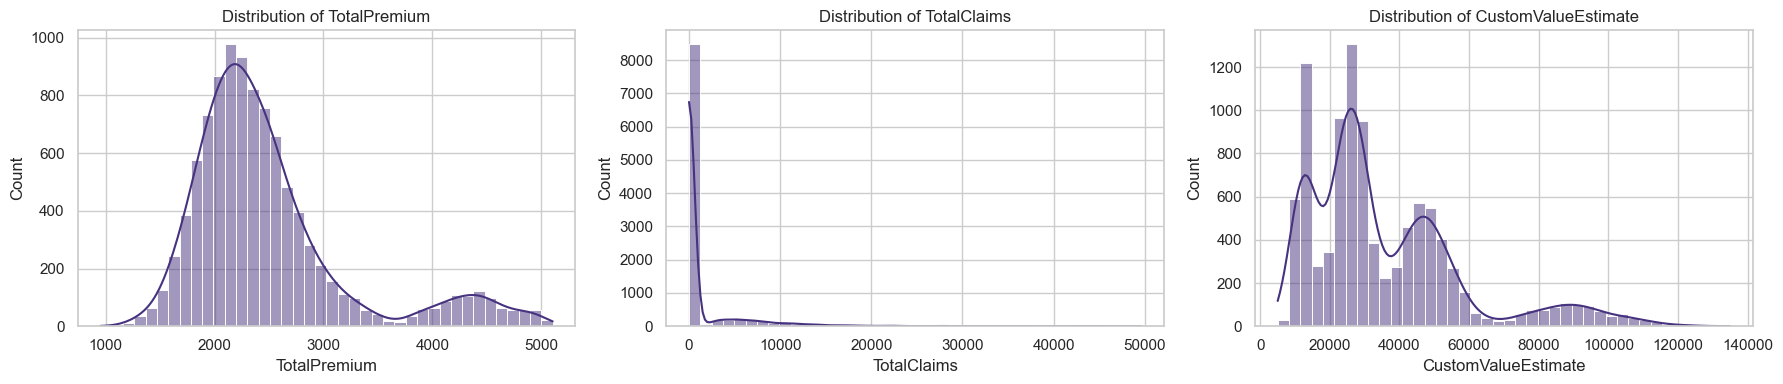

In [10]:
fig, axes = plt.subplots(1, len(key_numeric_cols), figsize=(6 * len(key_numeric_cols), 4))
if len(key_numeric_cols) == 1:
    axes = [axes]

for ax, column in zip(axes, key_numeric_cols):
    sns.histplot(df_risk[column].dropna(), kde=True, bins=40, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

**Business interpretation:** Skewed premium or claim distributions indicate that a small number of policies may drive a large share of financial risk. This is important for severity modeling because extreme claims can dominate model behavior.

## 7. Visualization 2: Outlier Detection with Box Plots

Box plots help identify extreme values in premiums, claims, and vehicle valuations.

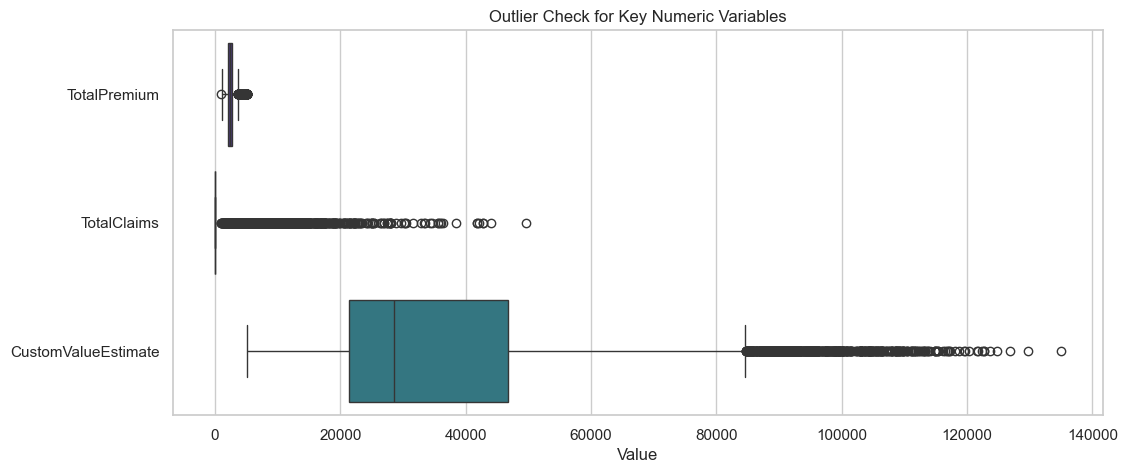

In [11]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_risk[key_numeric_cols], orient="h")
plt.title("Outlier Check for Key Numeric Variables")
plt.xlabel("Value")
plt.show()

**Business interpretation:** Outliers should not be removed automatically because they may represent genuine high-severity claims or high-value vehicles. They should be validated and handled carefully during modeling.

## 8. Visualization 3: Correlation Heatmap

A correlation heatmap helps identify numeric features related to premium, claims, margin, and vehicle value.

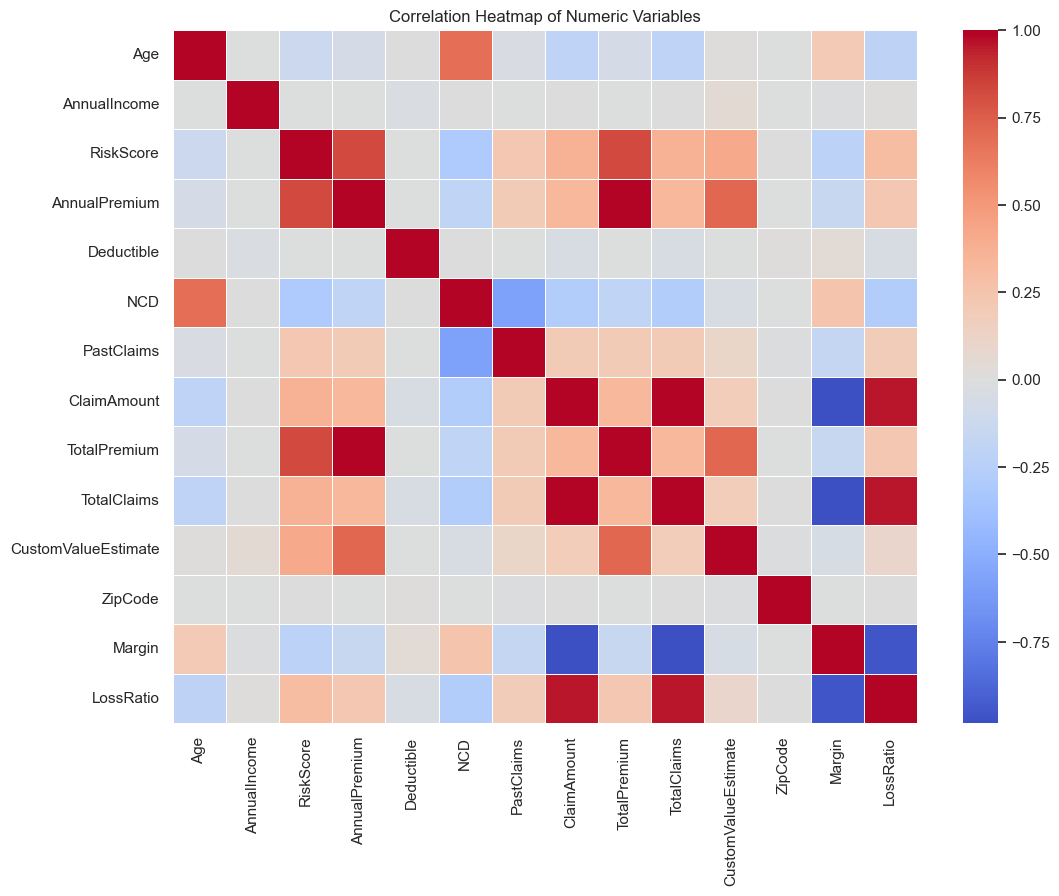

In [12]:
corr_columns = df_risk.select_dtypes(include="number").columns.tolist()
correlation_matrix = df_risk[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

**Business interpretation:** Strong correlations with claims or margin can suggest useful pricing and modeling features. Very high correlations between predictor variables may also indicate redundancy that should be considered during model building.

## 9. Segment Analysis by Province, Vehicle Type, and Gender

Compare loss ratio and margin across business-relevant groups to identify low-risk and high-risk segments.

In [13]:
province_summary = group_by_province(df_risk)
province_summary.head(15)

,Province,policy_count,total_premium,total_claims,average_premium,average_claim,loss_ratio,margin,margin_percentage
3,Somali,1184,2984984,1826593.0000,2521.1014,1542.7306,0.6119,1158391.0000,0.3881
2,Oromia,2446,6069663,3261061.0000,2481.4648,1333.2220,0.5373,2808602.0000,0.4627
4,Tigray,804,1990692,1047136.0000,2475.9851,1302.4080,0.5260,943556.0000,0.4740
0,Addis Ababa,3567,8907374,4653210.0000,2497.1612,1304.5164,0.5224,4254164.0000,0.4776
1,Amhara,1999,4928566,2353885.0000,2465.5158,1177.5313,0.4776,2574681.0000,0.5224


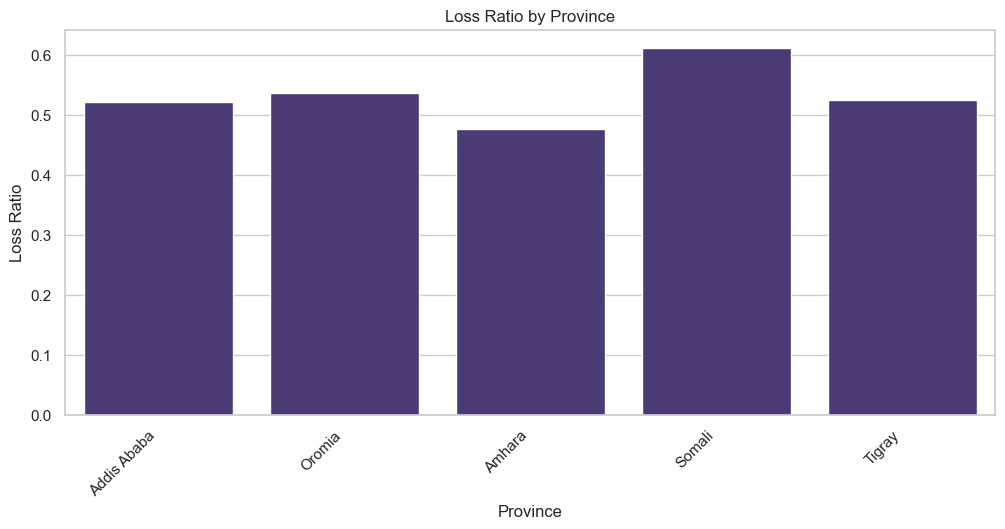

In [14]:
if "Province" in df_risk.columns:
    top_provinces = province_summary.sort_values("policy_count", ascending=False).head(10)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_provinces, x="Province", y="loss_ratio")
    plt.title("Loss Ratio by Province")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Loss Ratio")
    plt.show()

**Business interpretation:** Provinces with lower loss ratios and positive margins may be attractive for targeted growth. Provinces with high loss ratios may require pricing review, underwriting changes, or deeper investigation of claim drivers.

In [15]:
vehicle_type_summary = group_by_vehicle_type(df_risk)
vehicle_type_summary.head(15)

,VehicleType,policy_count,total_premium,total_claims,average_premium,average_claim,loss_ratio,margin,margin_percentage
1,Luxury,972,4236839,3569207.0000,4358.8879,3672.0237,0.8424,667632.0000,0.1576
2,SUV,3000,7256436,4090665.0000,2418.8120,1363.5550,0.5637,3165771.0000,0.4363
0,Hatchback,2036,4532134,1904235.0000,2225.9990,935.2824,0.4202,2627899.0000,0.5798
3,Sedan,3992,8855870,3577778.0000,2218.4043,896.2370,0.4040,5278092.0000,0.5960


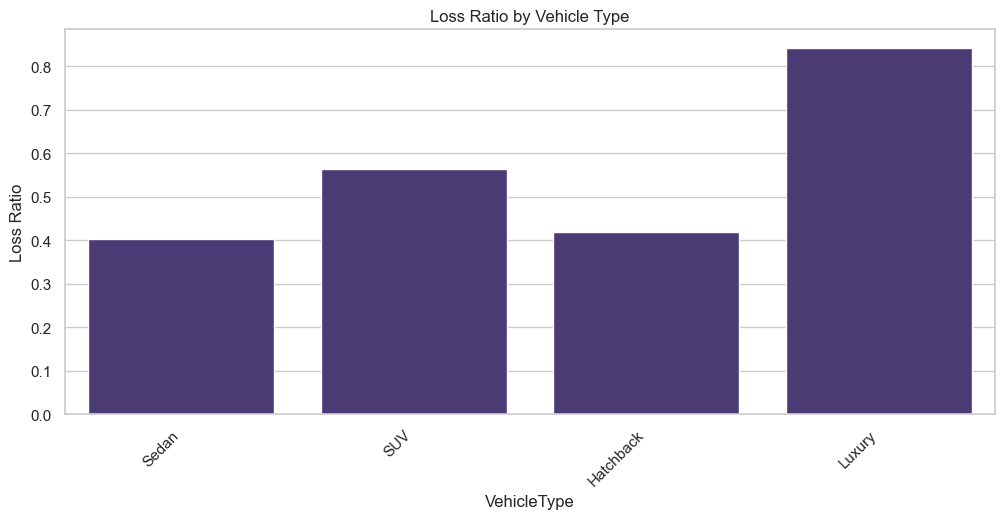

In [16]:
if "VehicleType" in df_risk.columns:
    top_vehicle_types = vehicle_type_summary.sort_values("policy_count", ascending=False).head(10)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_vehicle_types, x="VehicleType", y="loss_ratio")
    plt.title("Loss Ratio by Vehicle Type")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Loss Ratio")
    plt.show()

**Business interpretation:** Vehicle types with consistently high loss ratios may reflect higher repair costs, usage patterns, or theft/accident exposure. Low-loss vehicle types can support safer pricing and marketing strategies.

In [17]:
gender_summary = group_by_gender(df_risk)
gender_summary

,Gender,policy_count,total_premium,total_claims,average_premium,average_claim,loss_ratio,margin,margin_percentage
0,Female,5138,12791141,6763030.0000,2489.5175,1316.2768,0.5287,6028111.0000,0.4713
1,Male,4862,12090138,6378855.0000,2486.6594,1311.9817,0.5276,5711283.0000,0.4724


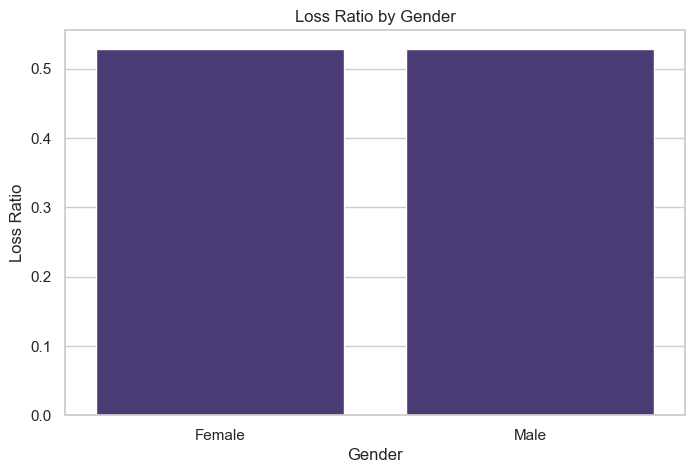

In [18]:
if "Gender" in df_risk.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=gender_summary, x="Gender", y="loss_ratio")
    plt.title("Loss Ratio by Gender")
    plt.ylabel("Loss Ratio")
    plt.show()

**Business interpretation:** Gender-level differences should be interpreted carefully and validated with hypothesis testing. Observed EDA differences may be influenced by exposure mix, vehicle types, location, and policy features.

## 10. Car Make and Model Analysis

Compare claim risk and margin across vehicle makes and models to identify vehicles associated with higher or lower insurance risk.

In [19]:
make_col = "make" if "make" in df_risk.columns else "Make" if "Make" in df_risk.columns else None
model_col = "Model" if "Model" in df_risk.columns else "model" if "model" in df_risk.columns else None

if make_col:
    make_summary = group_risk_summary(df_risk, make_col)
    display(make_summary.head(15))
else:
    print("No car make column found. Expected 'Make' or 'make'.")

No car make column found. Expected 'Make' or 'make'.


In [20]:
if model_col:
    model_summary = group_risk_summary(df_risk, model_col)
    display(model_summary.head(15))
else:
    print("No car model column found. Expected 'Model' or 'model'.")

No car model column found. Expected 'Model' or 'model'.


In [21]:
if make_col:
    top_makes = make_summary.sort_values("policy_count", ascending=False).head(15)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_makes, x=make_col, y="loss_ratio")
    plt.title("Loss Ratio by Car Make")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Loss Ratio")
    plt.show()

**Business interpretation:** Makes and models with high loss ratios may require adjusted pricing, tighter underwriting, or deeper inspection of repair cost and claim frequency. Low-risk vehicle groups may support more competitive premiums or targeted marketing.

## 11. Key Takeaways

Use this section to summarize the most important EDA findings before moving into hypothesis testing.

Suggested points to capture:

- Overall data quality issues and whether any fields require cleaning.
- Overall loss ratio and margin.
- Highest-risk and lowest-risk provinces.
- Vehicle types, makes, or models with unusual claim patterns.
- Any gender-level patterns that should be tested statistically.
- Outliers or skewed variables that may affect modeling.